In [16]:
import json
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

from collections import defaultdict

In [17]:
def get_metrics(stats, horizon=250, start_eval=0, theta_deg=10):
    success = np.array([k["Success_Rate"] for k in stats], dtype=float)

    # rzz: (N, horizon), pad with NaN after termination
    rzz = np.array([
        np.pad(
            np.asarray(k["Rzz_List"][:horizon], dtype=float),
            (0, horizon - min(len(k["Rzz_List"]), horizon)),
            constant_values=np.nan,
        )
        for k in stats
    ], dtype=float)

    success_rate = float(np.mean(success))

    T = rzz.shape[1]
    t = np.arange(T)[None, :]                 # (1, T)
    active = ~np.isnan(rzz)                   # (N, T)
    active_after = active & (t >= start_eval) # (N, T)

    # Mean Rzz only over active steps after start_eval
    rzz_after = np.where(active_after, rzz, np.nan)
    mean_rzz = np.nanmean(rzz_after, axis=1)  # (N,)

    # Threshold + violations
    trsh = float(np.cos(np.deg2rad(theta_deg)))
    viol = (rzz < trsh) & active_after        # (N, T)

    # Time to first violation (absolute index); if none, return NaN
    has_viol = viol.any(axis=1)
    #tt_first_viol = np.where(has_viol, viol.argmax(axis=1), np.nan)
    tt_first_viol = np.where(has_viol, viol.argmax(axis=1) - start_eval, np.nan)

    # Violation rate over active-after-start steps
    den = active_after.sum(axis=1)
    viol_rate = np.where(den > 0, viol.sum(axis=1) / den, np.nan)

    has_pos = all(("Pos_List" in k) and (k["Pos_List"] is not None) for k in stats)
    if has_pos:
        pos = np.full((len(stats), horizon, 3), np.nan, dtype=float)
        for i, k in enumerate(stats):
            arr = np.asarray(k["Pos_List"], dtype=float)
            L = min(arr.shape[0], horizon)
            pos[i, :L, :] = arr[:L, :3]
        return rzz, success_rate, mean_rzz, tt_first_viol, viol_rate, pos

    return rzz, success_rate, mean_rzz, tt_first_viol, viol_rate
    return rzz, success_rate, mean_rzz, tt_first_viol, viol_rate

### Picking the best policy 
1. Best Success for MH and PH --> both 1.0
2. which one has more diverse rollouts --> MH!

#### Success rate

In [18]:
ph_path = Path('../outputs/can_rollouts/base/mh_success/')
print('MH exec')

for file in ph_path.iterdir():

    with (file / 'rollout_stats.json').open() as f:
        stats = json.load(f )
        rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
        epoch = file.name.removeprefix('model_epoch_').removesuffix('.pth')
        print(f'{epoch}: {succes_rate}')
plt.plot(rzz.T)
plt.ylim([0.77, 1.02])
plt.show()

MH exec


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/can_rollouts/base/mh_success'

PH_exec
1800: 1.0
2000: 1.0
1400: 0.98
1200: 0.98
1000: 0.98
1600: 1.0


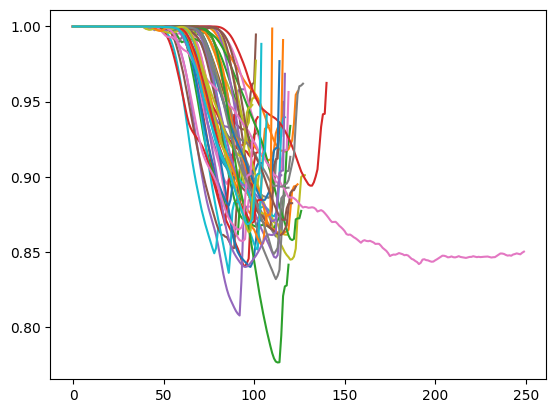

In [ ]:
ph_path = Path('../outputs/can_rollouts/base/ph_success/')
print('PH_exec')

for file in ph_path.iterdir():

    with (file / 'rollout_stats.json').open() as f:
        stats = json.load(f )
        rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats)
        epoch = file.name.removeprefix('model_epoch_').removesuffix('.pth')
        print(f'{epoch}: {succes_rate}')
plt.plot(rzz.T)
plt.show()

#### Policy Diversity

succes_rate: 1.0
mean_rzz: 0.9364113710457651
tt_trsh: 18.74
trsh_violation 0.6861020238699765


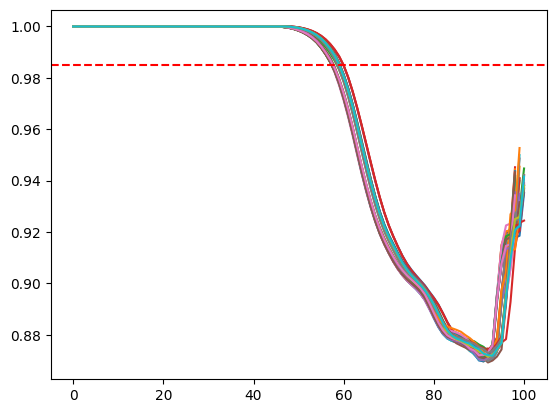

In [ ]:
# Hardcoded stats file path (20:17 run)
thrsh = 10

stats_path = Path("../outputs/can_rollouts/base/policy_diversity_ph/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats, start_eval=40, theta_deg=thrsh)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean)}\n'
      f'tt_trsh: {np.mean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )

plt.plot(rzz.T)
plt.axhline(np.cos(np.deg2rad(thrsh)), linestyle='--', color='red')
plt.show()


succes_rate: 1.0
mean_rzz: 0.9897041929499028
tt_trsh: 74.72340425531915
trsh_violation 0.30265348325446173


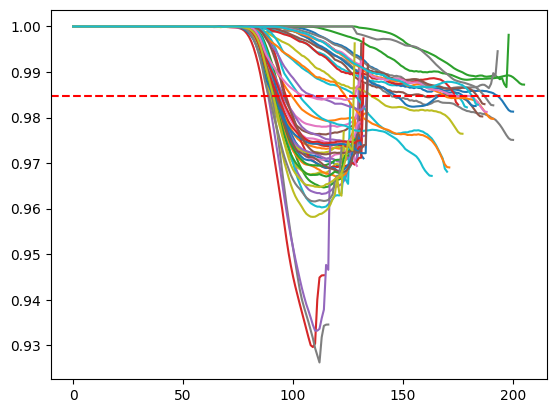

In [ ]:
# Hardcoded stats file path (20:17 run)
thrsh = 10
stats_path = Path("../outputs/can_rollouts/base/policy_diversity_mh_h300/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

rzz, succes_rate, mean, tt_trsh, trsh_violation = get_metrics(stats, start_eval=40, theta_deg=thrsh)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean)}\n'
      f'tt_trsh: {np.nanmean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )
      
plt.plot(rzz.T)
plt.axhline(np.cos(np.deg2rad(thrsh)), linestyle='--', color='red')
plt.show()


In [ ]:
stats_path = Path("/home/zoellner/src/guided-diffusion/outputs/can_rollouts/base/policy_diversity_mh_h300_pos/rollout_stats.json")

thrsh = 9
with stats_path.open() as f:
    stats = json.load(f)

rzz, succes_rate, mean, tt_trsh, trsh_violation, pos = get_metrics(stats, start_eval=0, theta_deg=thrsh)

print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean)}\n'
      f'tt_trsh: {np.nanmean(tt_trsh)}\n'
      f'violation_rate:{np.count_nonzero(~np.isnan(tt_trsh))/len(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )
# plt.plot(rzz.T)
# plt.axhline(np.cos(np.deg2rad(thrsh)), linestyle='--', color='red')
# plt.show()


succes_rate: 1.0
mean_rzz: 0.9974984573514977
tt_trsh: 141.73333333333332
violation_rate:0.6
trsh_violation 0.04528374920606185


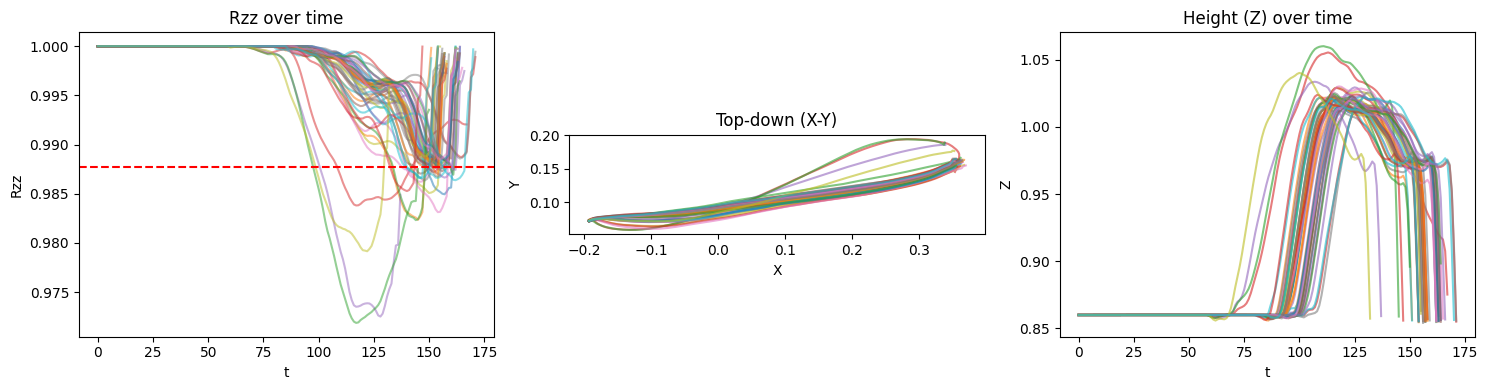

In [ ]:
thr = np.cos(np.deg2rad(thrsh))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---- 1) Rzz over time ----
axes[0].plot(rzz.T, alpha=0.5)
axes[0].axhline(thr, linestyle='--', color='red')
axes[0].set_title("Rzz over time")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Rzz")

# ---- 2) Top-down XY trajectories ----
for i in range(pos.shape[0]):
    axes[1].plot(pos[i,:,1], pos[i,:,0], alpha=0.6)
axes[1].set_title("Top-down (X-Y)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_aspect('equal')

# ---- 3) Z (height) over time ----
for i in range(pos.shape[0]):
    axes[2].plot(pos[i,:,2], alpha=0.6)
axes[2].set_title("Height (Z) over time")
axes[2].set_xlabel("t")
axes[2].set_ylabel("Z")

plt.tight_layout()
plt.show()

### Sample and Rank 
1. SR for fixed seed (50% baseline, 50% s/r) --> compare average angle 
2. SR for random seed over 100 runs (vs 100 runs of baseline)

In [ ]:
stats_path = Path("../outputs/can_rollouts/snr/n8h300r50g1/rollout_stats.json")
#stats_path = Path("../outputs/can_rollouts/snr/n8h300r40g1bYv2/rollout_stats.json")
# stats_path = Path("../outputs/can_rollouts/snr/n16h300r30g1bYv2/rollout_stats.json")
stats_path = Path("../outputs/can_rollouts/snr/n16h300r60g1bYfYv4/rollout_stats.json")

thrsh = 9 
with stats_path.open() as f: 
    stats = json.load(f)


# group stats by Mode
grouped = defaultdict(list)
for k in stats:
    grouped[k.get("Mode", "unknown")].append(k)

for mode, stats_subset in grouped.items():
    rzz, success_rate, mean, tt_trsh, trsh_violation, pos = get_metrics(
        stats_subset,
        start_eval=0,
        theta_deg=thrsh
    )

    print(f"\n=== {mode.upper()} ===")
    print(
        f"success_rate: {success_rate:.3f}\n"
        f"mean_rzz: {np.nanmean(mean):.5f}\n"
        f"tt_trsh (mean over viol only): {np.nanmean(tt_trsh):.2f}\n"
        f"ever_viol_rate: {np.mean(~np.isnan(tt_trsh)):.3f}\n"
        f"avg_viol_fraction: {np.nanmean(trsh_violation):.5f}"
    )



FileNotFoundError: [Errno 2] No such file or directory: '../outputs/can_rollouts/snr/n16h300r60g1bYfYv4/rollout_stats.json'

In [1]:
thr = np.cos(np.deg2rad(thrsh))

colors = {
    "baseline": "tab:blue",
    "sample_and_rank": "tab:orange",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for mode, stats_subset in grouped.items():
    rzz, _, _, _, _, pos = get_metrics(
        stats_subset,
        start_eval=0,
        theta_deg=thrsh
    )

    color = colors.get(mode, None)

    # ---- 1) Rzz ----
    for i in range(rzz.shape[0]):
        axes[0].plot(rzz[i], alpha=0.4, color=color)

    # ---- 2) XY ----
    if pos is not None:
        for i in range(pos.shape[0]):
            axes[1].plot(pos[i,:,1], pos[i,:,0], alpha=0.4, color=color)

    # ---- 3) Z ----
    if pos is not None:
        for i in range(pos.shape[0]):
            axes[2].plot(pos[i,:,2], alpha=0.4, color=color)

axes[0].axhline(thr, linestyle='--', color='red')
axes[0].set_title("Rzz over time")
axes[0].set_xlabel("t")
axes[0].set_ylabel("Rzz")
# axes[0].set_ylim([0.92,1.003])

axes[1].set_title("Top-down (X-Y)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_aspect('equal')

axes[2].set_title("Height (Z) over time")
axes[2].set_xlabel("t")
axes[2].set_ylabel("Z")

# legend
handles = [
    plt.Line2D([0], [0], color=colors[m], lw=2, label=m)
    for m in grouped.keys()
]
axes[0].legend(handles=handles)

plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

### Diffusion Guidance
- train a model that predicts Rzz after 16 steps (test for high accuracy)
- run diffusion based on the gradient through that model

In [ ]:
import h5py

gradient w.r.t predicted action horizon

---- 
until next meeting: 
Short-term STL: basically a reward function  = STL( obs )
f = STL(future-state(obs, actions_horizon))

future-state: NN -> current angle of can + action horizon -> outputs angle at the end
---> insert gradient basded on short-term STL with 'dumb' NN

----
dynamics/world model: 
try to generalize the dynamics model 'generalize' to allow for different short-term STLs (based on gripper, can position, etc..) 
latent space dynamics model (three networks: encoder - f(state) -> z , dynamics(z_t, a_t) -> z_t+1, decoder(z) -> cup angle (or later the full state))

----
1. Could combine: with novel stuff in optimization
-> adam (momentum + normailzation)
-> safe set projection 

2. Long-term STL:
--> predict a value for final robustness of STL based on RL (Product MDP of MDP x Automata)
--> if dynamics model doesnt work: learn dynamics for robustness conditioned on STL (i.e. a NN f(obs, action_horizon, STL))
    --> learn Q(s,a) , where Q = expected Robustness of trajectory w.r.t to STL over the distribution of trajectories of policy

3. Flow Matching:
--> ??? 

